# Проверка качества данных Online Retail II

В этом ноутбуке я загружу исходные данные интернет-магазина, посмотрю их структуру и найду основные проблемы: пропуски, дубликаты, отменённые заказы и некорректные значения.

## Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

## Загрузка данных

Excel-файл содержит два листа с транзакциями за разные периоды. Загрузим оба листа и объединим их в одну таблицу.

In [2]:
file_name = 'online_retail_II.xlsx'

df_2009 = pd.read_excel(file_name, sheet_name='Year 2009-2010', engine='openpyxl')
print(df_2009.shape)

(525461, 8)


In [3]:
df_2010 = pd.read_excel(file_name, sheet_name='Year 2010-2011', engine='openpyxl')
print(df_2010.shape)

(541910, 8)


In [4]:
df_2009['source_period'] = '2009-2010'
df_2010['source_period'] = '2010-2011'
df = pd.concat([df_2009, df_2010], ignore_index=True)
print(df.shape)
del df_2009, df_2010

(1067371, 9)


## Первичный просмотр

Посмотрим размер таблицы и несколько первых строк.

In [5]:
print('Строк:', df.shape[0])
print('Столбцов:', df.shape[1])

df.head()

Строк: 1067371
Столбцов: 9


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,source_period
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,2009-2010


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Invoice        1067371 non-null  object        
 1   StockCode      1067371 non-null  object        
 2   Description    1062989 non-null  object        
 3   Quantity       1067371 non-null  int64         
 4   InvoiceDate    1067371 non-null  datetime64[ns]
 5   Price          1067371 non-null  float64       
 6   Customer ID    824364 non-null   float64       
 7   Country        1067371 non-null  object        
 8   source_period  1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 73.3+ MB


Для удобства переименуем столбцы в `snake_case`.

In [7]:
df = df.rename(columns={'Invoice': 'invoice', 'StockCode': 'stock_code', 'Description': 'description', 'Quantity': 'quantity', 'InvoiceDate': 'invoice_date', 'Price': 'price', 'Customer ID': 'customer_id', 'Country': 'country'})

In [34]:
df.to_pickle('online_retail_raw.pkl')

In [9]:
df.columns

Index(['invoice', 'stock_code', 'description', 'quantity', 'invoice_date',
       'price', 'customer_id', 'country', 'source_period'],
      dtype='object')

## Основная информация о данных

Посчитаем количество уникальных счетов, товаров, покупателей и стран.

In [10]:
main_info = pd.Series({'rows': len(df), 'invoices': df['invoice'].nunique(), 'products': df['stock_code'].nunique(), 'customers': df['customer_id'].nunique(), 'countries': df['country'].nunique()})

main_info

rows         1067371
invoices       53628
products        5305
customers       5942
countries         43
dtype: int64

Посмотрим период, за который собраны данные.

In [11]:
print('Начало периода:', df['invoice_date'].min())
print('Конец периода:', df['invoice_date'].max())

Начало периода: 2009-12-01 07:45:00
Конец периода: 2011-12-09 12:50:00


In [12]:
df['source_period'].value_counts()

source_period
2010-2011    541910
2009-2010    525461
Name: count, dtype: int64

## Числовые столбцы

Посмотрим основные статистики количества товаров и цены.

In [13]:
df[['quantity', 'price']].describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,"1,067,371.00",9.94,172.71,"-80,995.00",1.00,3.00,10.00,"80,995.00"
price,"1,067,371.00",4.65,123.55,"-53,594.36",1.25,2.10,4.15,"38,970.00"


В минимальных значениях могут встречаться отрицательные количества и цены. Позже отдельно проверим, являются ли они ошибками или связаны с возвратами и служебными операциями.

## Пропуски

Посчитаем количество и долю пропущенных значений в каждом столбце.

In [14]:
missing = pd.DataFrame({'missing_count': df.isna().sum(), 'missing_percent': df.isna().mean() * 100})
missing = missing.sort_values('missing_count', ascending=False)

missing

,missing_count,missing_percent
customer_id,243007,22.77
description,4382,0.41
invoice,0,0.00
stock_code,0,0.00
quantity,0,0.00
invoice_date,0,0.00
price,0,0.00
country,0,0.00
source_period,0,0.00


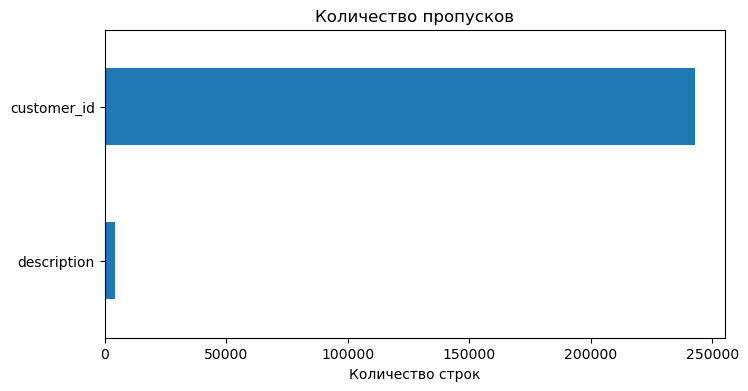

In [15]:
missing[missing['missing_count'] > 0]['missing_count'].sort_values().plot(kind='barh', figsize=(8, 4))
plt.title('Количество пропусков')
plt.xlabel('Количество строк')
plt.ylabel('')
plt.show()

Пропуски особенно важны в `customer_id`: без идентификатора покупателя строку можно использовать для анализа продаж, но нельзя использовать для когортного анализа, retention и RFM-сегментации.

## Дубликаты

Проверим количество полностью повторяющихся строк.

In [16]:
duplicates_count = df.duplicated().sum()

print('Полных дубликатов:', duplicates_count)
print('Доля дубликатов:', round(duplicates_count / len(df) * 100, 2), '%')

Полных дубликатов: 12133
Доля дубликатов: 1.14 %


In [17]:
df[df.duplicated(keep=False)].head(10)

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,source_period
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,2009-2010
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,2009-2010
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,2009-2010
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,"16,329.00",United Kingdom,2009-2010
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom,2009-2010
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,2009-2010
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom,2009-2010
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom,2009-2010
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,"16,329.00",United Kingdom,2009-2010
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,2009-2010


Обнаружено 12 133 полностью совпадающих строк, что составляет 1,14% данных. Перед удалением нужно проверить, являются ли они ошибками загрузки или повторяющимися позициями одного счёта.

## Отменённые операции

В датасете отменённые операции обозначаются буквой `C` в начале номера счёта.

In [18]:
cancelled_mask = df['invoice'].astype(str).str.startswith('C')

print('Строк с отменами:', cancelled_mask.sum())
print('Отменённых счетов:', df.loc[cancelled_mask, 'invoice'].nunique())
print('Доля строк с отменами:', round(cancelled_mask.mean() * 100, 2), '%')

Строк с отменами: 19494
Отменённых счетов: 8292
Доля строк с отменами: 1.83 %


In [19]:
df[cancelled_mask].head()

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,source_period
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia,2009-2010
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,"16,321.00",Australia,2009-2010
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,"16,321.00",Australia,2009-2010
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,"16,321.00",Australia,2009-2010
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia,2009-2010


Отменённые операции нельзя просто смешивать с обычными продажами. При дальнейшем анализе их нужно либо исключать, либо рассматривать отдельно как возвраты и отмены.

## Подозрительные значения

Проверим отрицательные и нулевые значения количества и цены.

In [20]:
quality_checks = pd.Series({'quantity_below_zero': (df['quantity'] < 0).sum(), 'quantity_equal_zero': (df['quantity'] == 0).sum(), 'price_below_zero': (df['price'] < 0).sum(), 'price_equal_zero': (df['price'] == 0).sum(), 'missing_customer_id': df['customer_id'].isna().sum(), 'missing_description': df['description'].isna().sum()})

quality_checks

quantity_below_zero     22950
quantity_equal_zero         0
price_below_zero            5
price_equal_zero         6202
missing_customer_id    243007
missing_description      4382
dtype: int64

In [21]:
df[df['price'] <= 0].head(10)

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,source_period
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom,2009-2010
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom,2009-2010
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom,2009-2010
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom,2009-2010
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom,2009-2010
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.00,NaN,United Kingdom,2009-2010
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom,2009-2010
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.00,NaN,United Kingdom,2009-2010
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.00,NaN,United Kingdom,2009-2010
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom,2009-2010


In [22]:
df[df['quantity'] < 0].head(10)

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,source_period
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia,2009-2010
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,"16,321.00",Australia,2009-2010
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,"16,321.00",Australia,2009-2010
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,"16,321.00",Australia,2009-2010
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia,2009-2010
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,"16,321.00",Australia,2009-2010
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,"16,321.00",Australia,2009-2010
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,"16,321.00",Australia,2009-2010
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia,2009-2010
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,"17,592.00",United Kingdom,2009-2010


Отрицательное количество часто связано с отменёнными операциями, но эту связь нужно проверить. Нулевые и отрицательные цены могут относиться к служебным строкам, скидкам или ошибкам.

In [23]:
pd.crosstab(df['quantity'] < 0, cancelled_mask)

invoice,False,True
quantity,,
False,1044420,1
True,3457,19493


Большая часть строк с отрицательным количеством относится к отменённым операциям: 19 493 строки имеют номер счёта с префиксом `C`.

При этом найдено ещё 3 457 строк с отрицательным количеством без такого префикса. Значит, определять возвраты только по номеру счёта недостаточно — необходимо дополнительно изучить описания и коды этих операций.

## Уникальные значения

Посмотрим количество уникальных значений в каждом столбце.

In [29]:
df.nunique().sort_values(ascending=False)

invoice          53628
invoice_date     47635
customer_id       5942
description       5698
stock_code        5305
price             2807
quantity          1057
country             43
source_period        2
dtype: int64

## Страны

Посмотрим страны с наибольшим количеством строк и счетов.

In [30]:
df['country'].value_counts().head(15)

country
United Kingdom     981330
EIRE                17866
Germany             17624
France              14330
Netherlands          5140
Spain                3811
Switzerland          3189
Belgium              3123
Portugal             2620
Australia            1913
Channel Islands      1664
Italy                1534
Norway               1455
Sweden               1364
Cyprus               1176
Name: count, dtype: int64

In [31]:
df.groupby('country')['invoice'].nunique().sort_values(ascending=False).head(15)

country
United Kingdom     49108
Germany             1095
EIRE                 806
France               746
Netherlands          250
Spain                188
Belgium              183
Sweden               129
Portugal             124
Switzerland          123
Australia            117
Italy                 92
Channel Islands       79
Finland               68
Japan                 56
Name: invoice, dtype: int64

Большая часть операций относится к Великобритании. При анализе стран нужно учитывать сильную разницу в количестве наблюдений.

## Проверка описаний товаров

Посмотрим строки без описания и наиболее частые значения поля `description`.

In [32]:
df[df['description'].isna()].head(10)

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,source_period
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom,2009-2010
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom,2009-2010
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.00,NaN,United Kingdom,2009-2010
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.00,NaN,United Kingdom,2009-2010
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom,2009-2010
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.00,NaN,United Kingdom,2009-2010
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.00,NaN,United Kingdom,2009-2010
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.00,NaN,United Kingdom,2009-2010
6576,489901,21098,NaN,-200,2009-12-03 09:47:00,0.00,NaN,United Kingdom,2009-2010
6581,489903,21166,NaN,48,2009-12-03 09:57:00,0.00,NaN,United Kingdom,2009-2010


In [33]:
df['description'].value_counts().head(20)

description
WHITE HANGING HEART T-LIGHT HOLDER    5918
REGENCY CAKESTAND 3 TIER              4412
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765
STRAWBERRY CERAMIC TRINKET BOX        2613
LUNCH BAG  BLACK SKULL.               2529
JUMBO STORAGE BAG SUKI                2434
HEART OF WICKER SMALL                 2319
JUMBO SHOPPER VINTAGE RED PAISLEY     2297
60 TEATIME FAIRY CAKE CASES           2271
PAPER CHAIN KIT 50'S CHRISTMAS        2215
LUNCH BAG SPACEBOY DESIGN             2206
REX CASH+CARRY JUMBO SHOPPER          2199
HOME BUILDING BLOCK WORD              2192
WOODEN FRAME ANTIQUE WHITE            2189
LUNCH BAG CARS BLUE                   2184
NATURAL SLATE HEART CHALKBOARD        2151
BAKING SET 9 PIECE RETROSPOT          2150
WOODEN PICTURE FRAME WHITE FINISH     2115
Name: count, dtype: int64

## Итоги первичного просмотра

В исходных данных обнаружены:

- пропуски в идентификаторах покупателей и описаниях товаров;
- полные дубликаты строк;
- отменённые операции;
- отрицательные значения количества;
- нулевые и отрицательные цены;
- сильная разница в количестве операций между странами.

На следующем этапе нужно определить правила очистки. При этом исходную таблицу следует сохранить без изменений, а очищенные данные записать в отдельный DataFrame.